# ДЗ. Приведение 6 рядов к стационарности

Схема: Бокс–Кокс → сезонность → тренд.
Критерий: ADF p < 0.05, KPSS p > 0.05, ACF без незатухающих сезонных пиков, нет передифференцирования (r ≤ −0.5 + рост дисперсии).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller, kpss, acf
from scipy.stats import boxcox_normmax
%matplotlib inline
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'font.size':9})

In [2]:
def load(f, col, kind):
    d = pd.read_csv('Series/'+f); k = d.columns[0]
    ix = (pd.PeriodIndex(d[k], freq='M').to_timestamp() if kind=='M'
          else pd.to_datetime(d[k]+'-1', format='%G-W%V-%u') if kind=='W'
          else pd.to_datetime(d[k]))
    return pd.Series(d[col].astype(float).values, index=ix)

def check(y, s, name=''):
    y = pd.Series(y).dropna().values; n = len(y)
    p_adf = adfuller(y, autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p_kpss = kpss(y, regression='c', nlags='auto')[1]   # p обрезан таблицей в [0.01, 0.10]
    r = acf(y, nlags=min(n//3, 3*s+2, 60), fft=False)
    print(f'{name:34s} n={n:4d}  ADF p={p_adf:.4f}  KPSS p={p_kpss:.3f}  '
          f'r1={r[1]:+.3f}  r{s}={r[s]:+.3f}  std={y.std():.4f}  (порог ACF ±{1.96/np.sqrt(n):.3f})')
    return dict(n=n, adf=p_adf, kpss=p_kpss, r1=r[1], rs=r[s])

def tsplot(y, lags, title):
    y = pd.Series(y).dropna()
    plt.figure(figsize=(11,6))
    ax = plt.subplot2grid((4,1),(0,0),rowspan=2); y.plot(ax=ax,lw=1); ax.set_title(title,fontsize=10)
    smt.graphics.plot_acf(y.values, lags=lags, ax=plt.subplot2grid((4,1),(2,0)), title='ACF')
    smt.graphics.plot_pacf(y.values, lags=lags, ax=plt.subplot2grid((4,1),(3,0)), title='PACF', method='ywm')
    plt.tight_layout(); plt.show()

def demean(y, s=None, trend=False):
    """Вычитание МНК: const + (тренд) + (сезонные дамми)."""
    y = pd.Series(y); n = len(y); t = np.arange(n)
    X = [np.ones(n)] + ([t] if trend else []) + ([(t%s==j).astype(float) for j in range(1,s)] if s else [])
    X = np.column_stack(X)
    return pd.Series(y.values - X @ np.linalg.lstsq(X, y.values, rcond=None)[0], index=y.index)

d1 = lambda y, k=1: pd.Series(y).diff(k).dropna()

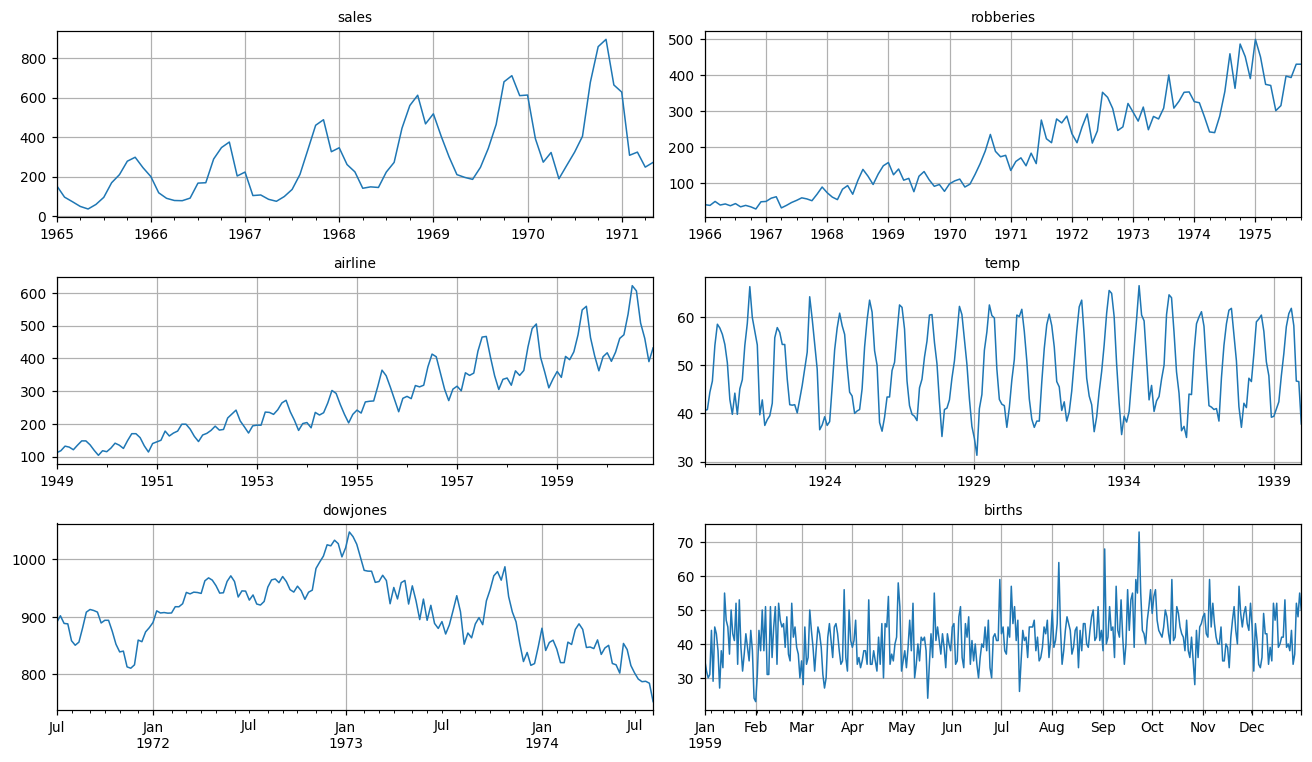

sales                              n=  77  ADF p=0.9889  KPSS p=0.010  r1=+0.871  r12=+0.676  std=197.1378  (порог ACF ±0.223)
robberies                          n= 118  ADF p=0.9943  KPSS p=0.010  r1=+0.928  r12=+0.668  std=127.4999  (порог ACF ±0.180)
airline                            n= 144  ADF p=0.9919  KPSS p=0.010  r1=+0.948  r12=+0.760  std=119.5490  (порог ACF ±0.163)
temp                               n= 240  ADF p=0.0170  KPSS p=0.100  r1=+0.808  r12=+0.884  std=8.5518  (порог ACF ±0.127)
dowjones                           n= 162  ADF p=0.6225  KPSS p=0.024  r1=+0.926  r52=-0.266  std=60.4126  (порог ACF ±0.154)
births                             n= 365  ADF p=0.0001  KPSS p=0.010  r1=+0.217  r7=+0.195  std=7.3382  (порог ACF ±0.103)


In [3]:
raw = {
 'sales':     load('monthly-sales-of-company-x-jan-6.csv','Count','M'),
 'robberies': load('monthly-boston-armed-robberies-j.csv','Count','M'),
 'airline':   load('international-airline-passengers.csv','Count','M'),
 'temp':      load('mean-monthly-air-temperature-deg.csv','Deg','M'),
 'dowjones':  load('weekly-closings-of-the-dowjones-.csv','Close','W'),
 'births':    load('daily-total-female-births-in-cal.csv','Count','D'),
}
S = {'sales':12,'robberies':12,'airline':12,'temp':12,'dowjones':52,'births':7}

fig, ax = plt.subplots(3,2,figsize=(12,7))
for a,(k,v) in zip(ax.ravel(), raw.items()):
    v.plot(ax=a,lw=1); a.set_title(k,fontsize=9); a.set_xlabel('')
plt.tight_layout(); plt.show()

for k,v in raw.items(): check(v, S[k], k)

Все шесть нестационарны. `temp` проходит ADF и KPSS, но r12 = 0.88 не затухает — сезонная нестационарность, тесты её не ловят.
`births`: ADF отвергает, KPSS(c) отвергает → трендовая стационарность (проверка ниже).

## 1. airline — log + Δ₁ + Δ₁₂

lambda = 0.148 -> лог
log                                n= 144  ADF p=0.4224  KPSS p=0.010  r1=+0.954  r12=+0.762  std=0.4399  (порог ACF ±0.163)
log + d1                           n= 143  ADF p=0.0711  KPSS p=0.100  r1=+0.200  r12=+0.841  std=0.1062  (порог ACF ±0.164)
log + d1 + d12                     n= 131  ADF p=0.0002  KPSS p=0.100  r1=-0.341  r12=-0.387  std=0.0457  (порог ACF ±0.171)


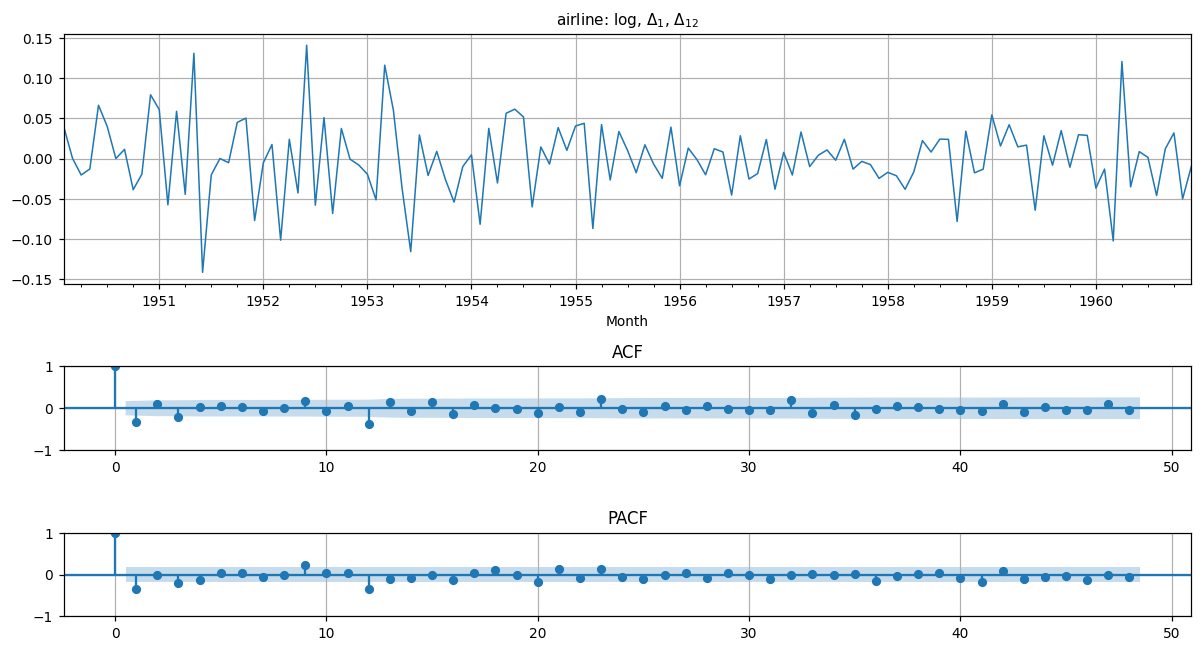

In [4]:
y = raw['airline']
print('lambda =', round(boxcox_normmax(y.values, method='mle'), 3), '-> лог')
L = np.log(y)
check(L, 12, 'log')
check(d1(L), 12, 'log + d1')                    # r12 = +0.84, сезонность осталась
air = d1(d1(L), 12)
check(air, 12, 'log + d1 + d12')                # ИТОГ
tsplot(air, 48, 'airline: log, $\\Delta_1$, $\\Delta_{12}$')

Стационарен. r1 = −0.34 и r12 = −0.39 — MA(1) и SMA(1) airline-модели, не передифференцирование: дисперсия упала 0.107 → 0.046.

## 2. robberies — log + Δ₁

lambda = 0.317 | std половин: 46.4 87.0 -> лог
log + d1                           n= 117  ADF p=0.0000  KPSS p=0.100  r1=-0.229  r12=+0.144  std=0.2062  (порог ACF ±0.181)
log + d1 + d12 (лишний)            n= 105  ADF p=0.0006  KPSS p=0.100  r1=-0.290  r12=-0.426  std=0.2712  (порог ACF ±0.191)


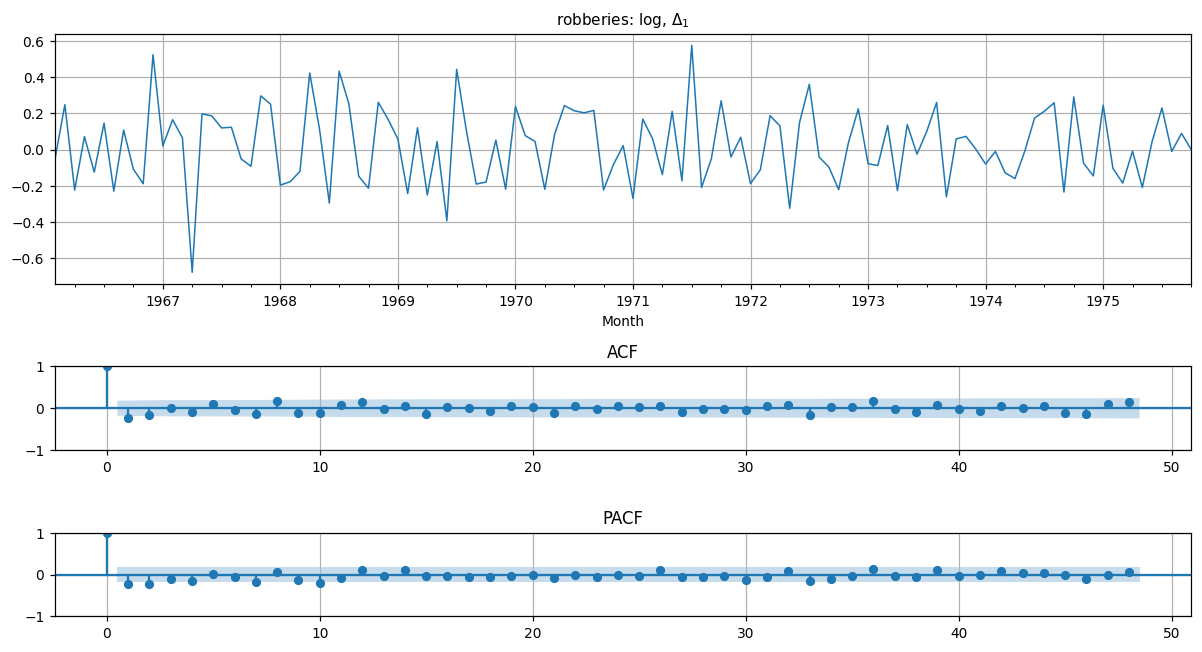

In [5]:
y = raw['robberies']
print('lambda =', round(boxcox_normmax(y.values, method='mle'), 3),
      '| std половин:', round(y[:59].std(),1), round(y[59:].std(),1), '-> лог')
L = np.log(y)
rob = d1(L)
check(rob, 12, 'log + d1')                      # ИТОГ; r12=+0.14 < порога 0.181 -> d12 НЕ нужен
check(d1(rob,12), 12, 'log + d1 + d12 (лишний)')# std растёт, r12 -> -0.43 = передифференцирование
tsplot(rob, 48, 'robberies: log, $\\Delta_1$')

## 3. sales — log + Δ₁ + сезонные дамми

lambda = 0.211 | std половин: 118.4 204.8 -> лог
log + d1                           n=  76  ADF p=0.0240  KPSS p=0.100  r1=+0.346  r12=+0.592  std=0.3256  (порог ACF ±0.225)
log + d1 + d12                     n=  64  ADF p=0.1668  KPSS p=0.100  r1=-0.583  r12=-0.356  std=0.2441  (порог ACF ±0.245)
log + d1 + сез. дамми              n=  76  ADF p=0.0433  KPSS p=0.100  r1=-0.410  r12=-0.225  std=0.1531  (порог ACF ±0.225)


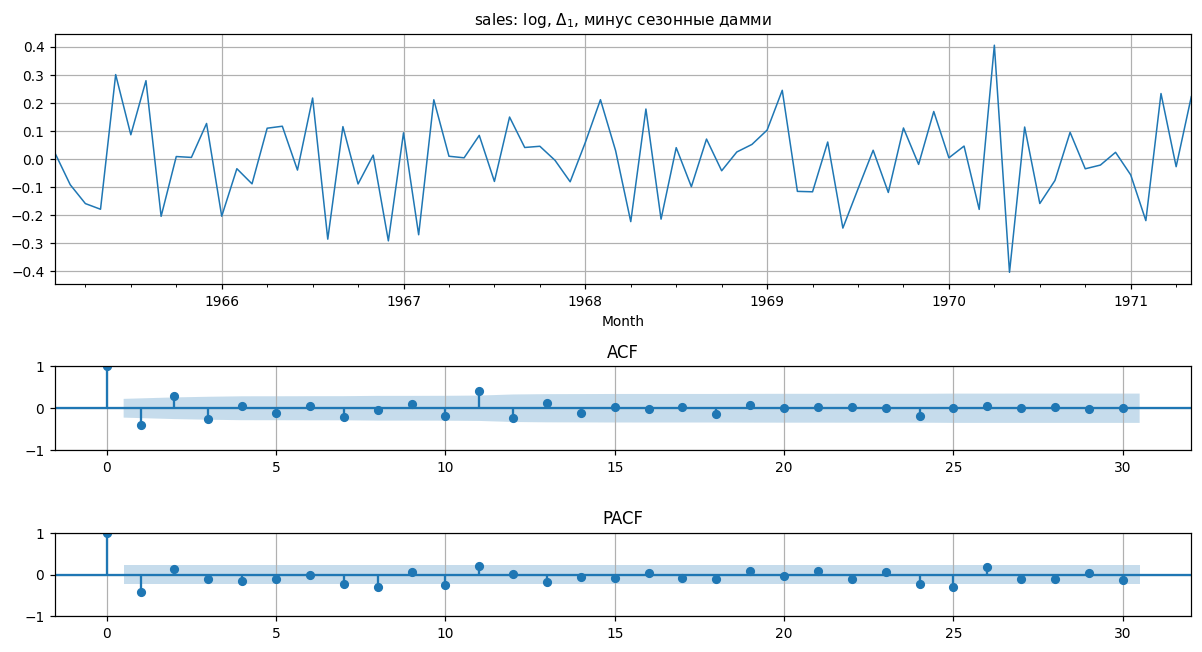

In [6]:
y = raw['sales']
print('lambda =', round(boxcox_normmax(y.values, method='mle'), 3),
      '| std половин:', round(y[:38].std(),1), round(y[38:].std(),1), '-> лог')
L = np.log(y)
check(d1(L), 12, 'log + d1')                    # r12=+0.59 -> сезонность значима
check(d1(d1(L),12), 12, 'log + d1 + d12')       # ADF p=0.17: n=64, мощности не хватает
sales = demean(d1(L), s=12)                     # ИТОГ: сезонность дамми, 76 наблюдений вместо 64
check(sales, 12, 'log + d1 + сез. дамми')
tsplot(sales, 30, 'sales: log, $\\Delta_1$, минус сезонные дамми')

Взят вариант с дамми: ADF и KPSS согласны. Вариант с Δ₁₂ тоже допустим — на n = 77 стохастическую и детерминированную сезонность не различить.

## 4. temp — минус месячные средние

std по 5-летиям: [8.01, 8.78, 9.08, 8.56] -> дисперсия стабильна, Бокс-Кокс не нужен
d12                                n= 228  ADF p=0.0000  KPSS p=0.100  r1=+0.195  r12=-0.626  std=3.4319  (порог ACF ±0.130)
минус месячные средние             n= 240  ADF p=0.0000  KPSS p=0.057  r1=+0.237  r12=-0.137  std=2.2546  (порог ACF ±0.127)


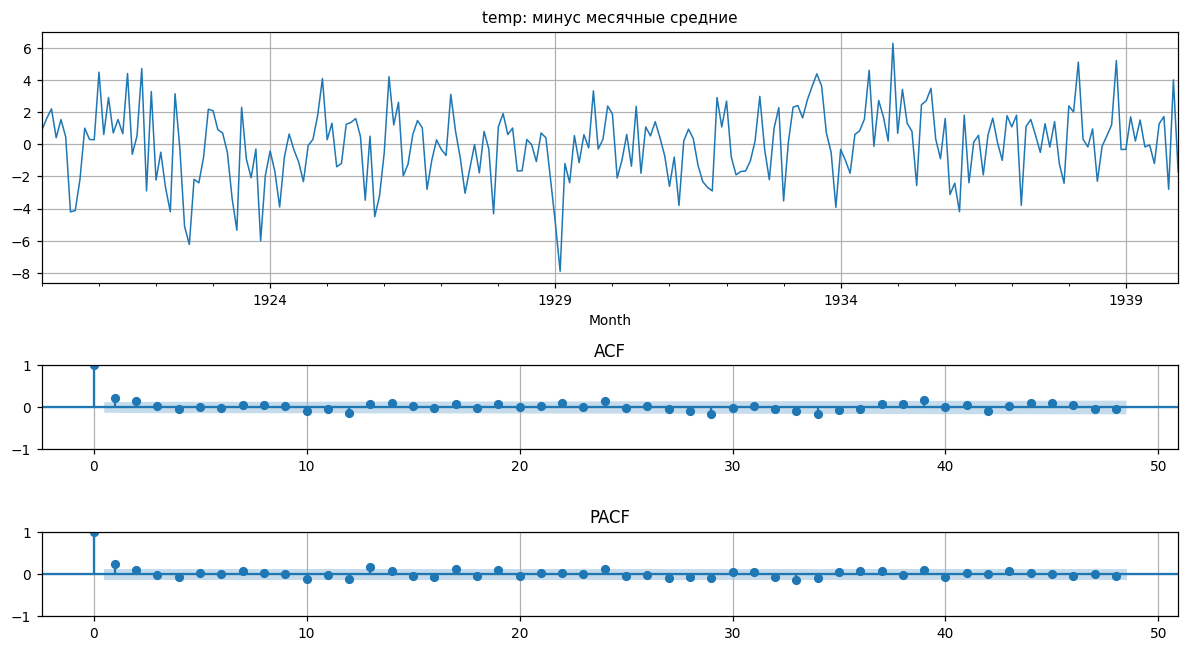

In [7]:
y = raw['temp']
print('std по 5-летиям:', [round(float(v),2) for v in pd.Series(y.values).groupby(np.arange(240)//60).std()],
      '-> дисперсия стабильна, Бокс-Кокс не нужен')
check(d1(y,12), 12, 'd12')                      # r12=-0.63 -> сезонное передифференцирование
temp = demean(y, s=12)                          # ИТОГ: сезонность детерминированная
check(temp, 12, 'минус месячные средние')
tsplot(temp, 48, 'temp: минус месячные средние')

Тренда нет, дифференцирование не нужно. KPSS p = 0.057 — на границе.

## 5. dowjones — log + Δ₁

lambda = 1.133 -> формально не нужен, лог берём для лог-доходностей
log + d1                           n= 161  ADF p=0.0000  KPSS p=0.100  r1=-0.042  r52=+0.014  std=0.0221  (порог ACF ±0.154)
d1 без лога (сравнение)            n= 161  ADF p=0.0000  KPSS p=0.100  r1=-0.042  r52=+0.003  std=19.7914  (порог ACF ±0.154)


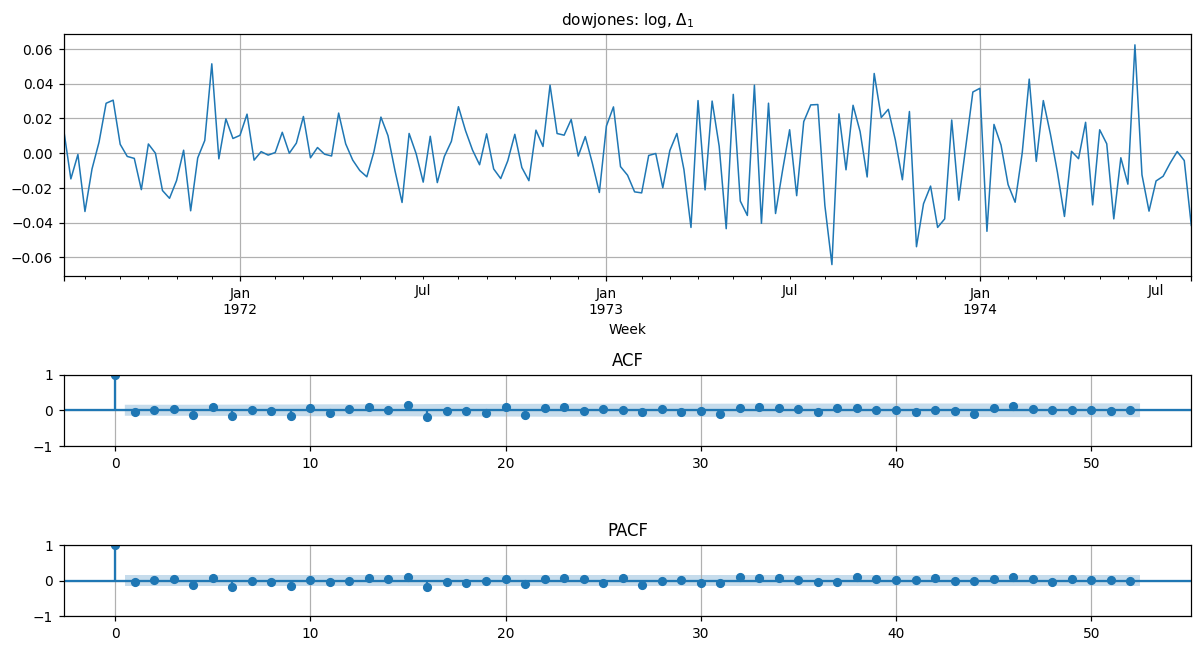

In [8]:
y = raw['dowjones']
print('lambda =', round(boxcox_normmax(y.values, method='mle'), 3),
      '-> формально не нужен, лог берём для лог-доходностей')
dj = d1(np.log(y))                              # ИТОГ
check(dj, 52, 'log + d1')
check(d1(y), 52, 'd1 без лога (сравнение)')
tsplot(dj, 52, 'dowjones: log, $\\Delta_1$')

r1 = −0.04 — приращения близки к белому шуму, ARIMA(0,1,0). Сезонности нет.

## 6. births — минус линейный тренд и дамми дней недели

KPSS c = 0.01 | KPSS ct = 0.063 -> стационарен вокруг тренда, дифференцировать нельзя
d1                                 n= 364  ADF p=0.0000  KPSS p=0.100  r1=-0.463  r7=+0.102  std=9.1772  (порог ACF ±0.103)
минус тренд                        n= 365  ADF p=0.0000  KPSS p=0.100  r1=+0.156  r7=+0.140  std=7.0573  (порог ACF ±0.103)
минус тренд и дамми дней нед.      n= 365  ADF p=0.0000  KPSS p=0.100  r1=+0.138  r7=+0.095  std=6.8691  (порог ACF ±0.103)


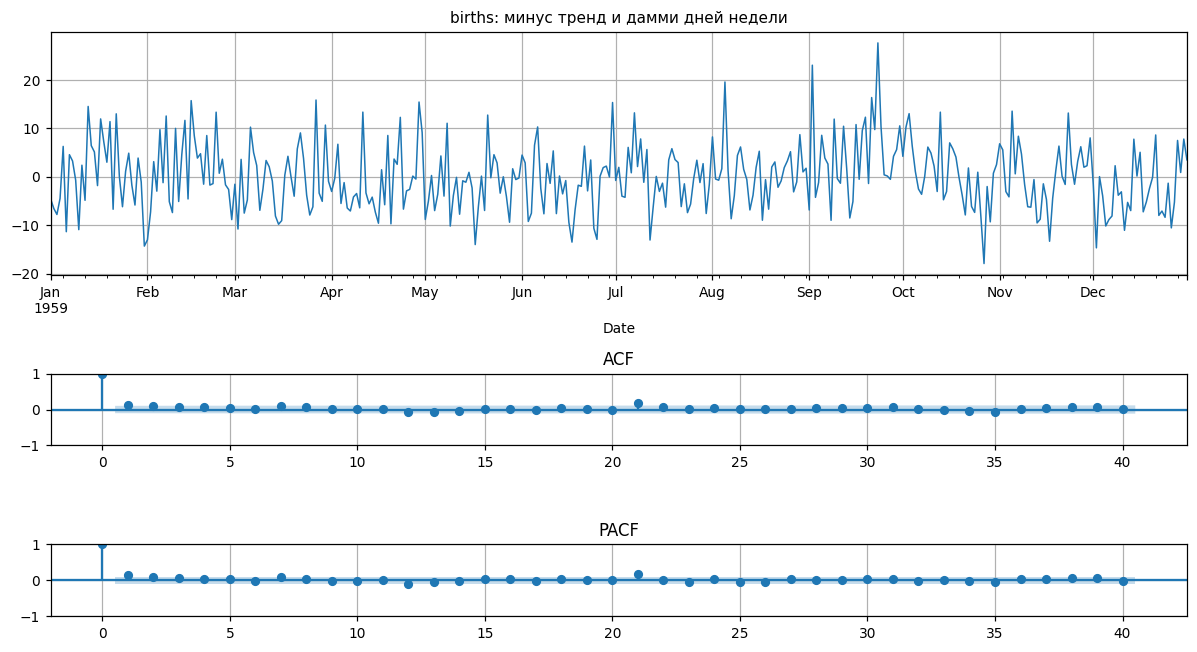

In [9]:
y = raw['births']
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    print('KPSS c =', round(kpss(y.values, regression='c',  nlags='auto')[1],3),
          '| KPSS ct =', round(kpss(y.values, regression='ct', nlags='auto')[1],3),
          '-> стационарен вокруг тренда, дифференцировать нельзя')
check(d1(y), 7, 'd1')                           # r1=-0.46, std 7.35 -> 9.19 = передифференцирование
births = demean(y, s=7, trend=True)             # ИТОГ
check(demean(y, trend=True), 7, 'минус тренд')  # r7=+0.14 -> добавляем дамми дней недели
check(births, 7, 'минус тренд и дамми дней нед.')
tsplot(births, 40, 'births: минус тренд и дамми дней недели')

## Итог

In [10]:
final = {'sales':(sales,'log + d1 + сезонные дамми'),
         'robberies':(rob,'log + d1'),
         'airline':(air,'log + d1 + d12'),
         'temp':(temp,'минус месячные средние'),
         'dowjones':(dj,'log + d1'),
         'births':(births,'минус тренд и дамми дней недели')}

rows=[]
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for k,(v,rec) in final.items():
        vv = pd.Series(v).dropna().values
        rows.append({'ряд':k,'преобразование':rec,
                     'ADF p':round(adfuller(vv,autolag='AIC')[1],4),
                     'KPSS p':round(kpss(vv,regression='c',nlags='auto')[1],3),
                     'n':len(vv)})
pd.DataFrame(rows).set_index('ряд')

,преобразование,ADF p,KPSS p,n
ряд,,,,
sales,log + d1 + сезонные дамми,0.0433,0.100,76
robberies,log + d1,0.0000,0.100,117
airline,log + d1 + d12,0.0002,0.100,131
temp,минус месячные средние,0.0000,0.057,240
dowjones,log + d1,0.0000,0.100,161
births,минус тренд и дамми дней недели,0.0000,0.100,365


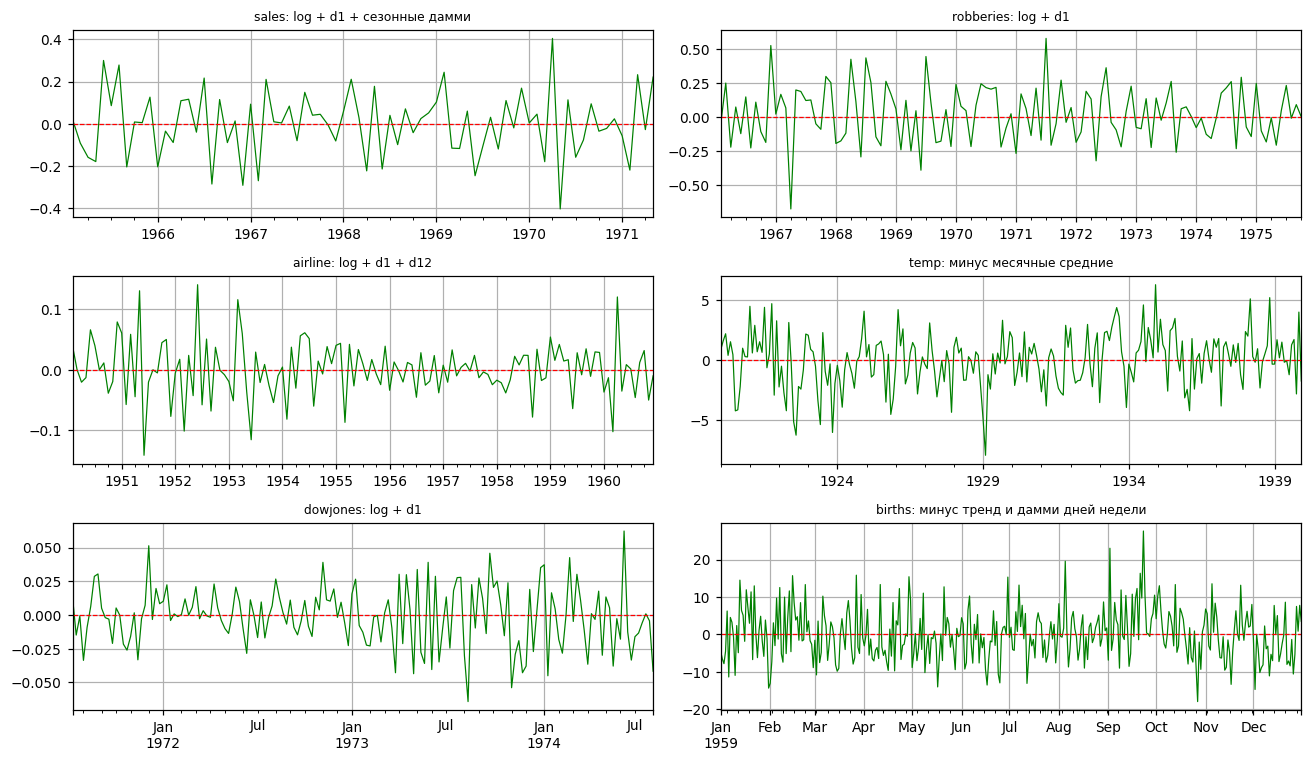

In [11]:
fig, ax = plt.subplots(3,2,figsize=(12,7))
for a,(k,(v,rec)) in zip(ax.ravel(), final.items()):
    pd.Series(v).plot(ax=a,lw=0.8,color='g'); a.axhline(0,color='r',ls='--',lw=0.8)
    a.set_title(f'{k}: {rec}',fontsize=8); a.set_xlabel('')
plt.tight_layout(); plt.show()

| ряд | преобразование |
|---|---|
| sales | log → Δ₁ → минус сезонные дамми |
| robberies | log → Δ₁ |
| airline | log → Δ₁ → Δ₁₂ |
| temp | минус месячные средние |
| dowjones | log → Δ₁ |
| births | минус линейный тренд и дамми дней недели |

Схема «log + Δ₁ + Δ₁₂» подошла только `airline`. Для `robberies`, `temp`, `births` она передифференцирует ряд.